<h1 style="font-size:30px;">Introduction to Segmentation Segmentation Using Torchvision</h1>


In this notebook, we will take a walkthrough on how to perform semantic segmentation inference using pre-trained models readily available in Torchvision.

<img src="https://opencv.org/wp-content/uploads/2023/06/c2_m4_segmentation_introduction_cover.png" width="80%">


Before diving deeper into the details of custom semantic segmentation, it's essential to have a good overview. Going through inference using pre-trained models can help us determine what kind of outputs the model returns and how to visualize them.


PyTorch's Torchvision library provides many pre-trained models. These models have been trained on images from the COCO dataset but only for the classes in the Pascal VOC dataset. Each model has been trained on thousands of images from 21 different classes.

As such, the Torchvision library contains several models belonging to the following semantic segmentation model families:
* DeepLabV3
* FCN (Fully Connected Network)
* Lite R-ASPP

## Table of Contents

* [1 Download Test images](#1-Download-Test-images)
* [2 Select Segmentation Model](#2-Select-Segmentation-Model)
* [3 Define A Prediction Function](#3-Define-A-Prediction-Function)
* [4 Define Class Color Mapping](#4-Define-Class-Color-Mapping)
* [5 Visualization Helper Functions](#5-Visualization-Helper-Functions)
* [6 Inference](#6-Inference)
* [7 Conclusion](#7-Conclusion)

In [1]:
#!pip install -qqqU torchinfo

In [2]:
#!pip install opencv-python

In [3]:
#!pip install numpy==1.26.1

In [4]:
import os
import glob
import zipfile

import cv2
import requests
import numpy as np
from torchinfo import summary
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as TF

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 1 Download Test images

In [5]:
# To download and unzip processed dataset.

def download_and_unzip(url, save_path):

    print("Downloading and extracting assets...", end="")
    file = requests.get(url)
    open(save_path, "wb").write(file.content)

    try:
        with zipfile.ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0]) # Unzip where downloaded.
            print("Done")
    except:
        print("Invalid file")

In [6]:
URL = r"https://www.dropbox.com/s/guewjolncoge5si/sample_segmentation_VOC_images.zip?dl=1"

dataset_name = "sample_segmentation_VOC_images"
dataset_zip_path = os.path.join(os.getcwd(), f"{dataset_name}.zip")
dataset_path = os.path.join(os.getcwd(), dataset_name)

# Download if dataset does not exists.
if not os.path.exists(dataset_path):
    download_and_unzip(URL, dataset_zip_path)

## 2 Select Segmentation Model

The `get_model(...)` function defined below will load and return any segmentation model in evaluation mode provided you pass the correct model name.

In [7]:
def get_model(model_name, pretrained=True):

    # Initialize Segmentation model.
    weights = "DEFAULT" if pretrained else None
    model   = getattr(torchvision.models.segmentation, MODEL_NAME)(weights=weights)

    # Set model to evaluation mode.
    model.eval()

    return model

**Below is the table listing all the models available in Torchvision.**

| **# No.** | **Model**                    | **mIOU** | **Pixel Acc.** | **Num. Parameters** | **GFLOPS** |
|:---------:|:----------------------------:|:--------:|:--------------:|:-------------------:|:----------:|
| 1         | **deeplabv3_mobilenet_v3_large** | 60.3     | 91.2           | 11.0M               | 10.45      |
| 2         | **deeplabv3_resnet50**           | 66.4     | 92.4           | 42.0M               | 178.72     |
| 3         | **deeplabv3_resnet101**          | 67.4     | 92.4           | 61.0M               | 258.74     |
| 4         | **fcn_resnet50**                 | 60.5     | 91.4           | 35.3M               | 258.74     |
| 5         | **fcn_resnet101**                | 63.7     | 91.9           | 54.3M               | 232.74     |
| 6         | **lraspp_mobilenet_v3_large**    | 57.9     | 91.2           | 3.2M                | 2.09       |


In [8]:
# Choose any model from the above table.
MODEL_NAME = "deeplabv3_resnet50"

# Create model.
model = get_model(MODEL_NAME)

# Print model summary using a random sized input.
summary(model, input_size=(1, 3, 256, 256))

28.5%

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


Layer (type:depth-idx)                             Output Shape              Param #
DeepLabV3                                          [1, 21, 256, 256]         --
├─IntermediateLayerGetter: 1-1                     [1, 2048, 32, 32]         --
│    └─Conv2d: 2-1                                 [1, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                            [1, 64, 128, 128]         128
│    └─ReLU: 2-3                                   [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                              [1, 64, 64, 64]           --
│    └─Sequential: 2-5                             [1, 256, 64, 64]          --
│    │    └─Bottleneck: 3-1                        [1, 256, 64, 64]          75,008
│    │    └─Bottleneck: 3-2                        [1, 256, 64, 64]          70,400
│    │    └─Bottleneck: 3-3                        [1, 256, 64, 64]          70,400
│    └─Sequential: 2-6                             [1, 512, 32, 32]          --
│    │    └─Bottlen

**Here, `FCNHead` refers to the layers in the auxiliary branch.**

## 3 Define A Prediction Function



In this section, we will define a `predict(...)` function to help run inference on input images.

The Torchvision model returns an output of type `OrderedDict`, a dictionary. The dictionary contains two keys, `out` & `aux`. The `out` key holds the model output segmentation logits. The `aux` key holds the output from the auxiliary branch of the model. The auxiliary branch is not required during inference, and during training, it's used to help reduce the vanishing gradient problem for earlier layers, stabilizes the training, and is used as regularization.

**We are only interested in the `out` key.**

In [9]:
def predict(image, model, device):
    """
    Runs prediction by taking an image tensor
    and the model.

    :param image: Image tensor, shape: [N, H, W, C].
    :param model: The segmentation model.
    :param device: The compute device.

    Returns:
        outputs: Segmentation logits tensor.
    """

    image = image.unsqueeze(0) # Add a batch dimension
    image = image.to(device)   # Load on to compute device.

    model = model.to(device)   # Load model on to compute device.

    with torch.no_grad():      # Inference within .no_grad() context manager as
        outputs = model(image) # gradients are not required.

    return outputs["out"]

## 4 Define Class Color Mapping

The models available in Torchvision have been trained on classes from the Pascal VOC dataset, and the images for those classes are taken from the COCO dataset as it has a better variety of images.

Here, we define a color mapping for each class in the Pascal VOC dataset.

In [10]:
# Pascal VOC daset color mapping.
label_color_map = [
    (0, 0, 0),       # background
    (128, 0, 0),     # aeroplane
    (0, 128, 0),     # bicycle
    (128, 128, 0),   # bird
    (0, 0, 128),     # boat
    (128, 0, 128),   # bottle
    (0, 128, 128),   # bus
    (128, 128, 128), # car
    (64, 0, 0),      # cat
    (192, 0, 0),     # chair
    (64, 128, 0),    # cow
    (192, 128, 0),   # dining table
    (64, 0, 128),    # dog
    (192, 0, 128),   # horse
    (64, 128, 128),  # motorbike
    (192, 128, 128), # person
    (0, 64, 0),      # potted plant
    (128, 64, 0),    # sheep
    (0, 192, 0),     # sofa
    (128, 192, 0),   # train
    (0, 64, 128),    # tv/monitor
]

## 5 Visualization Helper Functions

The following function creates the final segmentation map from the output logits.

In [19]:
def draw_segmentation_map(outputs, label_map):
    """
    Creates an RGB segmentation mask where the background
    is black and the detected objects are colored pixels
    corresponding to the class in `label_color_map`.

    :param outputs: Mask logits from the segmentation model.
    :param label_map: The label color map corresponding to each class.

    Returns:
        segmentation_map: The final segmentation map.
    """
    labels = torch.argmax(outputs.squeeze(), dim=0).detach().to('cpu').numpy()

    # Create 3 Numpy arrays containing zeros.
    # Later each pixel will be filled with respective red, green, and blue pixels
    # depending on the predicted class.

    red_map   = np.zeros_like(labels).astype(np.uint8)
    green_map = np.zeros_like(labels).astype(np.uint8)
    blue_map  = np.zeros_like(labels).astype(np.uint8)

    for label_num in range(0, len(label_map)):
        index = labels == label_num

        R, G, B = label_map[label_num]

        red_map[index]   = R
        green_map[index] = G
        blue_map[index]  = B

    segmentation_map = np.stack([red_map, green_map, blue_map], axis=2)
    return segmentation_map

We do not want to visualize only the mask. That will also give us insights but not much. Instead we can overlay the segmentation map on top of the original image. This will allow us to visualize whether each of the predicted object masks encompass the correct object or not.

In [20]:
# Function to overlay a segmentation map on top of an RGB image.
def image_overlay(image, segmented_image):
    """
    Overlays the segmentation map on the top of the original
    image.

    :param image: An image, NumPy array.
    :param segmented_image: Segmentation map.

    Returns:
        image: The final image with overlayed mask.
    """

    alpha = 1.0 # Transparency for the original image.
    beta  = 0.7 # Transparency for the segmentation map.
    gamma = 0.0 # Scalar added to each sum.

    segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    image = cv2.addWeighted(image, alpha, segmented_image, beta, gamma)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image

Plot and visualize images in a 2x2 grid.

In [21]:
def visualize(result_dir):
    """
    Function accepts a list of images and plots
    them in a 2x2 grid.
    """
    plt.figure(figsize=(12, 9))
    image_names = glob.glob(os.path.join(result_dir, "*.jpg"))
    for i, image_name in enumerate(image_names):
        image = plt.imread(image_name)
        plt.subplot(2, 2, i + 1)
        plt.imshow(image)
        plt.axis("off")
    plt.tight_layout()

    # plt.savefig("test.jpg", bbox_inches='tight')
    plt.show()

## 6 Inference

**Data Preprocessing Transforms**

We also need to properly transform the input images.

1. We will convert the input image to a `PIL` image format.
2. Recale the pixel values to between from `[0, 255]` -->`[0.0, 1.0]` and convert to PyTorch tensor type using `ToTensor`. It also permutes the channel dimension as required in PyTorch, i.e., [H, W, C] --> [C, H, W]
3. Then, the image will be normalized according to the ImageNet dataset normalization values as the model backbones were trained on the ImageNet dataset; we are using the ImageNet normalization values here.

During training, the images were also reshaped to size between `[260, 1040]`. Here we will not do so and perform inference on the original image size.

In [22]:
# Define the torchvision image transforms
def get_transforms():
    return TF.Compose(
        [
            TF.ToPILImage(),
            TF.ToTensor(),
            TF.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

In the following code block, we first define the image transforms. Then we initialize the computing device. This may be the CPU or GPU, depending on the availability.

In [23]:
transforms = get_transforms()

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [24]:
# Create an output directory.
OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

In this final section,

1. We loop over the image paths to load and preprocess each image.
2. Perform a forward pass through the model.
3. Save the results to disk.

In [25]:
# # Choose any other model from the table.
# MODEL_NAME = "deeplabv3_mobilenet_v3_large"

# # Create model.
# model = get_model(MODEL_NAME)

for image_name in os.listdir(dataset_path):
    # Read and preprocess image.
    image = cv2.imread(os.path.join(dataset_path, image_name))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_transformed = transforms(image)

    # Generate Predictions.
    outputs = predict(image_transformed, model, device)

    # Convert outputs to RGB image.
    segmentation_map = draw_segmentation_map(outputs, label_color_map)

    # Create an overlay image of RGB Image and RGB Segmentation map.
    overlayed_image = image_overlay(image, segmentation_map)

    # Convert overlayed image to BGR format and save to disk.
    cv2.imwrite(os.path.join(OUT_DIR, image_name), overlayed_image[:, :, ::-1])

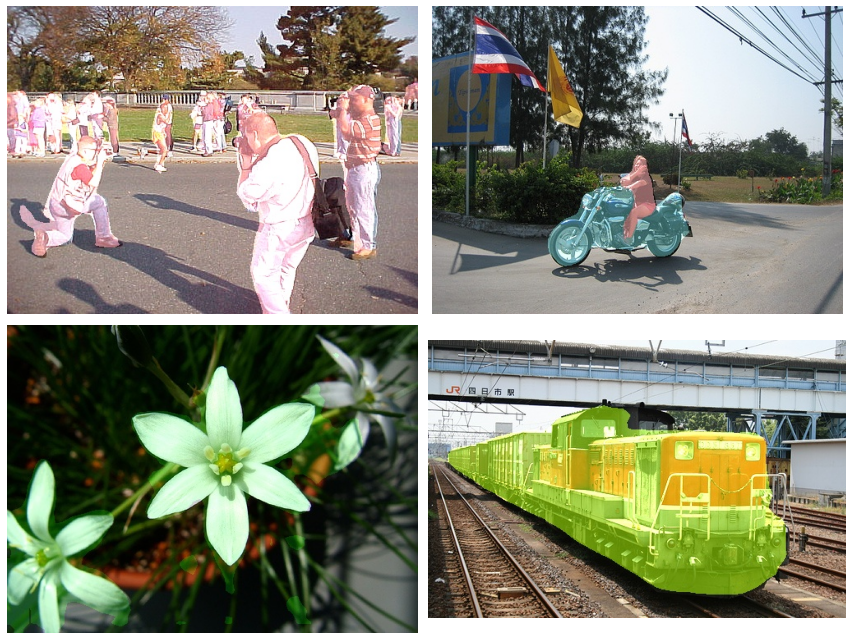

In [26]:
visualize(OUT_DIR)

## 7 Conclusion

In this notebook, we ran inferences on images using Torchvision segmentation pre-trained models. Specifically, we chose the DeepLabV3 ResNet50 model for semantic segmentation. In the next unit's notebooks, you will also learn how to structure your custom dataset and fine-tune such pre-trained models on the datasets.